Plot example signals from the raw files

In [1]:
import tifffile as tf
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio

These are two img.tif files converted with MATLAB or python

This is probably the 3rd file checked

In [2]:
imgPy = tf.memmap(r"E:\L6 Experiments\L608\FOV1\SEDS_day11_FOV1_optoRec_LBC0_noProbe\SEDS_day11_FOV1_optoRec_LBC0_noProbe_img\img.tif")
imgMat = tf.memmap(r"E:\L6 Experiments\L608\FOV1\SEDS_day11_FOV1_optoRec_LBC0_noProbe\SEDS_day11_FOV1_optoRec_LBC0_noProbe_img\imgMat.tif")

# load interpolated samples
intPy = sio.loadmat(r"E:\L6 Experiments\L608\FOV1\SEDS_day11_FOV1_optoRec_LBC0_noProbe\SEDS_day11_FOV1_optoRec_LBC0_noProbe_img\ledArtifactDataInterp.mat")
intMat = sio.loadmat(r"E:\L6 Experiments\L608\FOV1\SEDS_day11_FOV1_optoRec_LBC0_noProbe\SEDS_day11_FOV1_optoRec_LBC0_noProbe_img\ledArtifactDataInterpMat.mat")

Detected artifacts from both codes.

Note that pythons code searches each plane independently and interpolates images in a specific plane. MATLABs code runs this algorithm over the full max projection. Pythons version would be more accurate.

In [9]:
pyArtifact  = intPy['ledArtifact']['Axis0'][0][0][0]
matArtifact = intMat['ledArtifact']-1
print("Python artifact index:",pyArtifact)
print("Matlab artifact index:",matArtifact.flatten())
#intMat['ledArtifact'][0][0][0]

Python artifact index: [  792  1349 30197]
Matlab artifact index: [  792  1349 30197]


Matlabs version should have one extra sample at the end

In [10]:
print('pyImg:',imgPy.shape)
print('matImg',imgMat.shape)

pyImg: (40727, 512, 512)
matImg (40728, 512, 512)


Raw images

The only point at which these images differ are during the artifacts, which the algorithms may work differently in interpolation, aside from the fact that they are interpolated differently (python interpolates the planes separately, matlab interpolates the max proj img)

Number of non-zero elements: 0


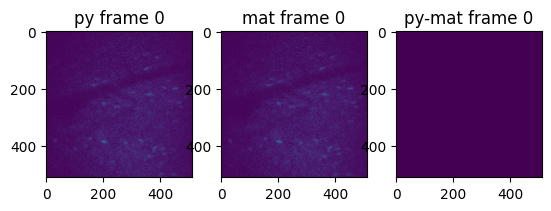

In [35]:
#i = pyArtifact[2]
i = 0
fig, ax = plt.subplots(nrows=1,ncols=3)
ax[0].imshow(imgPy[i]); ax[0].set_title(f"py frame {i}")
ax[1].imshow(imgMat[i]); ax[1].set_title(f"mat frame {i}")
ax[2].imshow(imgPy[i]-imgMat[i]); ax[2].set_title(f"py-mat frame {i}")

# Indices where the condition is met 
indices = np.where(imgPy[i] - imgMat[i] != 0)

# Flatten the result to a 1D array 
flat_indices = np.ravel_multi_index(indices, imgPy[100].shape)
print("Number of non-zero elements:",len(flat_indices))

Get max projection over time to compare datasets. Note that we exclude the last datapoint from the MATLAB img

In [ ]:
#maxPy = np.max(imgPy,axis=0)
#maxMat = np.max(imgMat[:-1],axis=0)

# Calculate max values, excluding elements found in pyArtifact
maxPy = np.max(np.where(pyArtifact, -np.inf, imgPy), axis=0)
maxMat = np.max(np.where(pyArtifact, -np.inf, imgMat[:-1]), axis=0)

print("maxPy:", maxPy)
print("maxMat:", maxMat)


ValueError: operands could not be broadcast together with shapes (3,) () (40727,512,512) 

The figure below should end up blank when subtracting the two max projection images. If so, then we know they operate similar enough.

Number of non-zero elements: 16


array([ 11508,  26512,  54375,  55863,  57790,  65545, 106088, 121903,
       127048, 135462, 137971, 185157, 190120, 191066, 199834, 230962],
      dtype=int64)

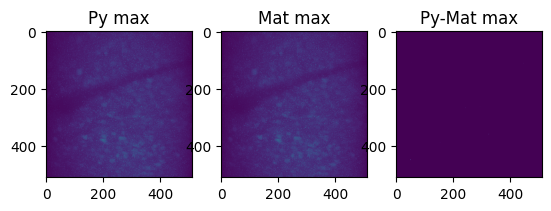

In [25]:
fig, ax = plt.subplots(nrows=1,ncols=3)
ax[0].imshow(maxPy); ax[0].set_title("Py max")
ax[1].imshow(maxMat); ax[1].set_title("Mat max")
ax[2].imshow(maxPy-maxMat); ax[2].set_title("Py-Mat max")

# Indices where the condition is met 
indices = np.where(maxPy - maxMat != 0)

# Flatten the result to a 1D array 
flat_indices = np.ravel_multi_index(indices, maxPy.shape)
print("Number of non-zero elements:",len(flat_indices))
flat_indices

In [13]:
np.min(maxPy-maxMat)
#np.max(maxPy-maxMat)

0